# Analyse et Prédiction de Pokémon
## Préparation des données | Analyse Exploratoire | Machine Learning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Configuration
plt.style.use('default')
sns.set_palette('husl')

# 1. PRÉPARATION DES DONNÉES

In [ ]:
# Charger les données
pokemon = pd.read_csv('pokemon.csv', index_col='#')
combats = pd.read_csv('combats.csv')
tests = pd.read_csv('tests.csv')

print("Pokémon shape:", pokemon.shape)
print("Combats shape:", combats.shape)
print("Tests shape:", tests.shape)
print("\nAperçu pokemon.csv:")
print(pokemon.head())

Pokémon shape: (800, 11)
Combats shape: (50000, 3)
Tests shape: (10000, 2)

Aperçu pokemon.csv:
            Name Type 1  Type 2  HP  Attack  Defense  Sp. Atk  Sp. Def  Speed  \
#                                                                               
1      Bulbasaur  Grass  Poison  45      49       49       65       65     45   
2        Ivysaur  Grass  Poison  60      62       63       80       80     60   
3       Venusaur  Grass  Poison  80      82       83      100      100     80   
4  Mega Venusaur  Grass  Poison  80     100      123      122      120     80   
5     Charmander   Fire     NaN  39      52       43       60       50     65   

   Generation  Legendary  
#                         
1           1      False  
2           1      False  
3           1      False  
4           1      False  
5           1      False  


In [ ]:
# Corriger les valeurs manquantes
print("Pokémon #62 avant correction:")
print(pokemon.loc[62])

# Vérifier et corriger Name manquant si nécessaire
if pd.isna(pokemon.loc[62, 'Name']):
    pokemon.loc[62, 'Name'] = 'Primeape'
    print("\nNom corrigé: Primeape")
else:
    print(f"\nPokémon #62 a le nom: {pokemon.loc[62, 'Name']}")

Pokémon #62 avant correction:
Name            Mankey
Type 1        Fighting
Type 2             NaN
HP                  40
Attack              80
Defense             35
Sp. Atk             35
Sp. Def             45
Speed               70
Generation           1
Legendary        False
Name: 62, dtype: object

Pokémon #62 a le nom: Mankey


In [ ]:
# Gérer Type 2 - remplacer NaN par "Aucun"
print(f"Valeurs manquantes dans Type 2 avant: {pokemon['Type 2'].isna().sum()}")
pokemon['Type 2'] = pokemon['Type 2'].fillna('Aucun')
print(f"Valeurs manquantes dans Type 2 après: {pokemon['Type 2'].isna().sum()}")
print(f"\nPokémon avec Type 2 = 'Aucun': {(pokemon['Type 2'] == 'Aucun').sum()}")

Valeurs manquantes dans Type 2 avant: 386
Valeurs manquantes dans Type 2 après: 0

Pokémon avec Type 2 = 'Aucun': 386


In [ ]:
# Calculer le pourcentage de victoire pour chaque Pokémon
victory_counts = combats['Winner'].value_counts()
total_battles = pd.concat([combats['First_pokemon'], combats['Second_pokemon']]).value_counts()

victory_percentage = {}
for pokemon_id in pokemon.index:
    wins = victory_counts.get(pokemon_id, 0)
    battles = total_battles.get(pokemon_id, 0)
    if battles > 0:
        victory_percentage[pokemon_id] = (wins / battles) * 100
    else:
        victory_percentage[pokemon_id] = 0

pokemon['Win_Percentage'] = pokemon.index.map(victory_percentage)

print(f"Pokémon avec au moins 1 combat: {(pokemon['Win_Percentage'] > 0).sum()}/{len(pokemon)}")
print(f"\nStatistiques du pourcentage de victoires:")
print(pokemon['Win_Percentage'].describe())

Pokémon avec au moins 1 combat: 783/800

Statistiques du pourcentage de victoires:
count    800.000000
mean      49.088060
std       26.244249
min        0.000000
25%       27.419355
50%       47.928067
75%       70.917793
max       98.449612
Name: Win_Percentage, dtype: float64


# 2. ANALYSE EXPLORATOIRE ET VISUALISATION

In [ ]:
# Sélectionner les colonnes pertinentes pour la corrélation
stats_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Win_Percentage']
correlation_data = pokemon[stats_cols]

# Matrice de corrélation
print("Corrélation avec Win_Percentage:")
corr_matrix = correlation_data.corr()
print(corr_matrix[['Win_Percentage']].sort_values(by='Win_Percentage', ascending=False))

Corrélation avec Win_Percentage:
                Win_Percentage
Win_Percentage        1.000000
Speed                 0.905409
Attack                0.476675
Sp. Atk               0.455848
Sp. Def               0.291603
HP                    0.234889
Defense               0.113312


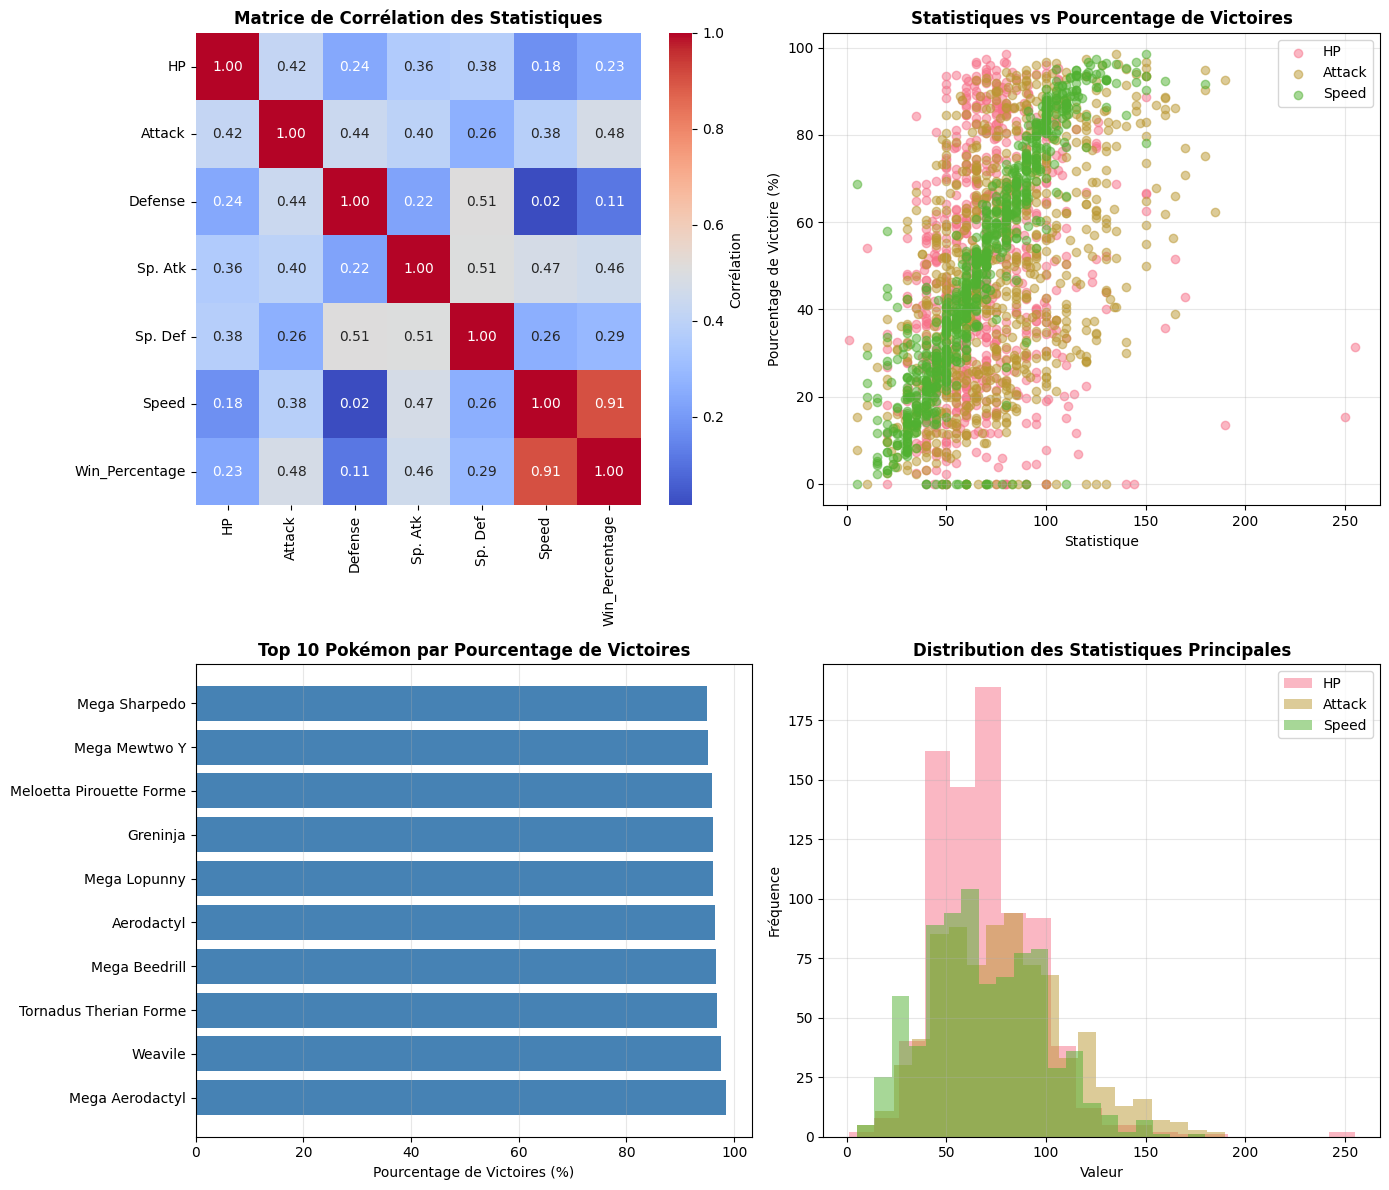


Top 10 Pokémon par Pourcentage de Victoires:
                         Name   HP  Attack  Speed  Win_Percentage
#                                                                
155           Mega Aerodactyl   80     135    150       98.449612
513                   Weavile   70     120    125       97.478992
704    Tornadus Therian Forme   79     100    121       96.800000
20              Mega Beedrill   65     150    145       96.638655
154                Aerodactyl   80     105    130       96.453901
477              Mega Lopunny   65     136    135       96.124031
727                  Greninja   72      95    122       96.062992
717  Meloetta Pirouette Forme  100     128    128       95.934959
165             Mega Mewtwo Y  106     150    140       95.200000
350             Mega Sharpedo   70     140    105       95.000000


In [ ]:
# Créer les visualisations
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Heatmap de corrélation
ax1 = axes[0, 0]
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax1, cbar_kws={'label': 'Corrélation'})
ax1.set_title('Matrice de Corrélation des Statistiques', fontsize=12, fontweight='bold')

# Statistiques vs Win Percentage
ax2 = axes[0, 1]
scatter_cols = ['HP', 'Attack', 'Speed']
for col in scatter_cols:
    ax2.scatter(pokemon[col], pokemon['Win_Percentage'], alpha=0.5, label=col)
ax2.set_xlabel('Statistique')
ax2.set_ylabel('Pourcentage de Victoire (%)')
ax2.set_title('Statistiques vs Pourcentage de Victoires', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Top 10 Pokémon
ax3 = axes[1, 0]
top10 = pokemon.nlargest(10, 'Win_Percentage')[['Name', 'Win_Percentage']]
ax3.barh(top10['Name'], top10['Win_Percentage'], color='steelblue')
ax3.set_xlabel('Pourcentage de Victoires (%)')
ax3.set_title('Top 10 Pokémon par Pourcentage de Victoires', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')

# Distribution des statistiques
ax4 = axes[1, 1]
for col in scatter_cols:
    ax4.hist(pokemon[col], alpha=0.5, label=col, bins=20)
ax4.set_xlabel('Valeur')
ax4.set_ylabel('Fréquence')
ax4.set_title('Distribution des Statistiques Principales', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTop 10 Pokémon par Pourcentage de Victoires:")
print(pokemon.nlargest(10, 'Win_Percentage')[['Name', 'HP', 'Attack', 'Speed', 'Win_Percentage']])

# 3. MACHINE LEARNING - MODÈLES DE RÉGRESSION

In [ ]:
# Préparer les données d'entraînement
X = pokemon[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']].copy()
y = pokemon['Win_Percentage'].copy()

# Division 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Ensemble d'entraînement: {X_train.shape[0]} samples")
print(f"Ensemble de test: {X_test.shape[0]} samples")

Ensemble d'entraînement: 640 samples
Ensemble de test: 160 samples


In [ ]:
# Modèle 1: Régression Linéaire
print("=" * 60)
print("Régression Linéaire")
print("=" * 60)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
print(f"MAE (Test): {mae_lr:.4f}")

# Coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=False)
print("\nCoefficients:")
print(coef_df)

Régression Linéaire
MAE (Test): 6.4915

Coefficients:
   Feature  Coefficient
5    Speed     0.778146
1   Attack     0.113595
2  Defense     0.022670
0       HP     0.021578
4  Sp. Def     0.006745
3  Sp. Atk    -0.024813


In [ ]:
# Modèle 2: Random Forest
print("\n" + "=" * 60)
print("Random Forest")
print("=" * 60)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
print(f"MAE (Test): {mae_rf:.4f}")

# Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nImportance des features:")
print(importance_df)


Random Forest
MAE (Test): 5.7331

Importance des features:
   Feature  Importance
5    Speed    0.883789
1   Attack    0.043876
4  Sp. Def    0.024242
3  Sp. Atk    0.017295
0       HP    0.016555
2  Defense    0.014243


In [ ]:
# Modèle 3: XGBoost
print("\n" + "=" * 60)
print("XGBoost")
print("=" * 60)
xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
print(f"MAE (Test): {mae_xgb:.4f}")

# Feature importance
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nImportance des features:")
print(xgb_importance)


XGBoost
MAE (Test): 6.5788

Importance des features:
   Feature  Importance
5    Speed    0.888934
1   Attack    0.037947
4  Sp. Def    0.029783
3  Sp. Atk    0.016637
0       HP    0.015388
2  Defense    0.011310


In [ ]:
# Comparaison des modèles
print("\n" + "=" * 60)
print("COMPARAISON DES MODÈLES (MAE)")
print("=" * 60)
results = pd.DataFrame({
    'Modèle': ['Régression Linéaire', 'Random Forest', 'XGBoost'],
    'MAE': [mae_lr, mae_rf, mae_xgb]
}).sort_values('MAE')
print(results.to_string(index=False))

# Meilleur modèle
best_model = results.iloc[0]
print(f"\n🏆 Meilleur modèle: {best_model['Modèle']} (MAE: {best_model['MAE']:.4f})")


COMPARAISON DES MODÈLES (MAE)
             Modèle      MAE
      Random Forest 5.733053
Régression Linéaire 6.491538
            XGBoost 6.578771

🏆 Meilleur modèle: Random Forest (MAE: 5.7331)


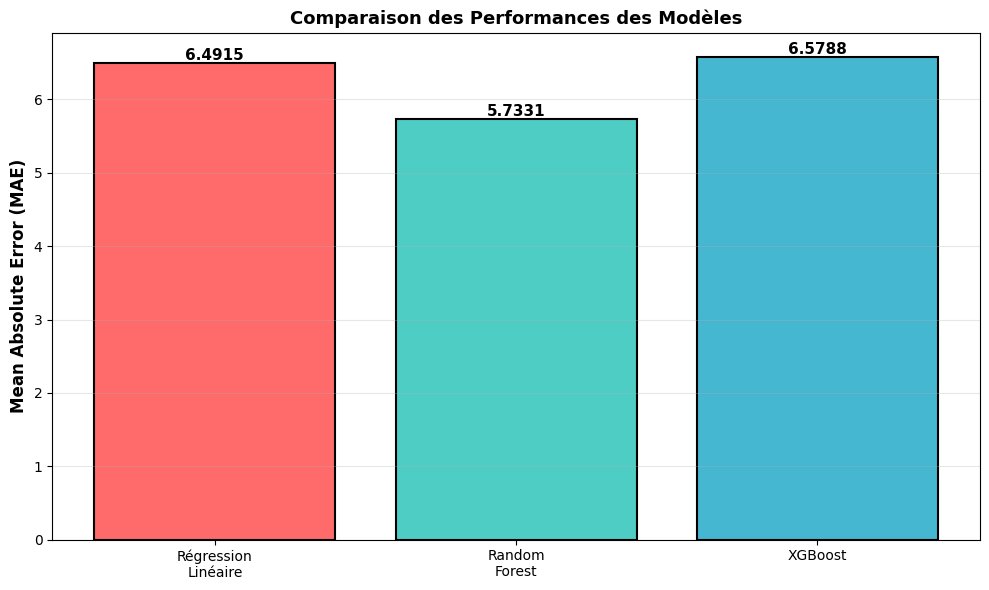

In [ ]:
# Visualisation des performances
fig, ax = plt.subplots(figsize=(10, 6))
models = ['Régression\nLinéaire', 'Random\nForest', 'XGBoost']
mae_values = [mae_lr, mae_rf, mae_xgb]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax.bar(models, mae_values, color=colors, edgecolor='black', linewidth=1.5)

# Ajouter les valeurs sur les barres
for bar, mae in zip(bars, mae_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{mae:.4f}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
ax.set_title('Comparaison des Performances des Modèles', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# Ensemble de test - prédictions
print("="*60)
print("ENSEMBLE DE TEST")
print("="*60)
print(f"Nombre de combats à prédire: {tests.shape[0]}")
print("\nAperçu de l'ensemble de test:")
print(tests.head(10))

ENSEMBLE DE TEST
Nombre de combats à prédire: 10000

Aperçu de l'ensemble de test:
   First_pokemon  Second_pokemon
0            129             117
1            660             211
2            706             115
3            195             618
4             27             656
5            126             222
6            436             207
7            121              36
8            169             636
9            302             688
